# AQI Forecasting — ARIMA Model
**Dataset:** AnandVihar_AQI_data.csv  
**Target:** Daily mean AQI  
**Model:** ARIMA(2,1,2)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_squared_error, mean_absolute_error

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 1. Load & Preprocess Data

In [2]:
# Load data
df = pd.read_csv('D:/AQI_Project/Data/Final/Colaba_AQI_daily_clean.csv', parse_dates=['Timestamp'])
df = df.set_index('Timestamp').sort_index()

# Interpolate missing AQI values (only 7 missing)
df['AQI'] = df['AQI'].interpolate(method='time')

# Resample to daily mean
daily = df['AQI'].resample('D').mean().dropna()

print(f'Total daily records: {len(daily)}')
print(f'Date range: {daily.index[0].date()} to {daily.index[-1].date()}')
print(f'AQI stats:\n{daily.describe()}')

Total daily records: 1826
Date range: 2021-01-01 to 2025-12-31
AQI stats:
count    1826.000000
mean       94.040515
std        59.015638
min        17.086667
25%        49.044583
50%        80.098958
75%       118.615938
max       386.450417
Name: AQI, dtype: float64


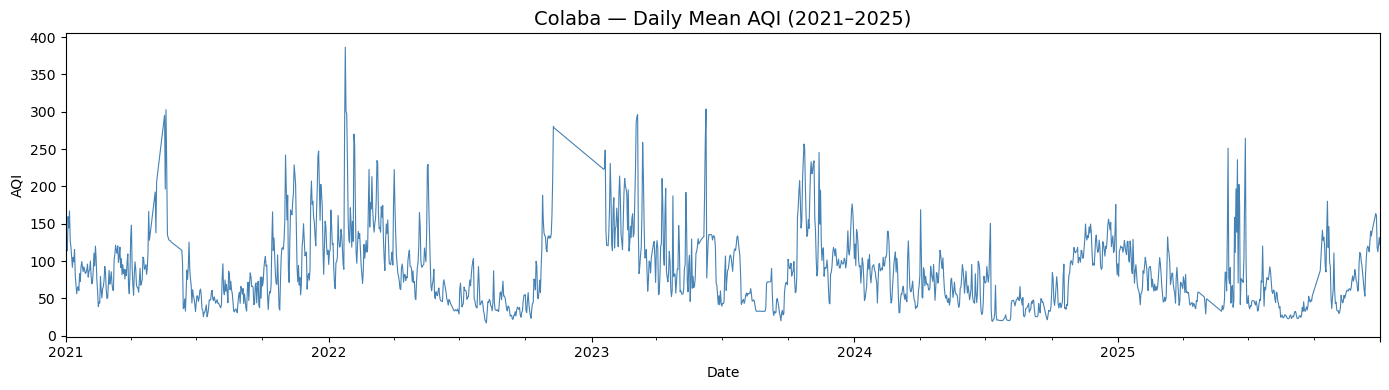

In [3]:
# Plot the full time series
fig, ax = plt.subplots(figsize=(14, 4))
daily.plot(ax=ax, color='steelblue', linewidth=0.8)
ax.set_title('Colaba — Daily Mean AQI (2021–2025)', fontsize=14)
ax.set_ylabel('AQI')
ax.set_xlabel('Date')
plt.tight_layout()
plt.savefig('arima_full_series_Colaba.png', dpi=150)
plt.show()

## 2. Stationarity Check (ADF Test)

In [4]:
result = adfuller(daily.dropna())
print('ADF Test on original series:')
print(f'  ADF Statistic : {result[0]:.4f}')
print(f'  p-value       : {result[1]:.4f}')
print(f'  Critical 1%   : {result[4]["1%"]:.4f}')
print(f'  Critical 5%   : {result[4]["5%"]:.4f}')
print()
if result[1] < 0.05:
    print('Series is STATIONARY (d=0 may suffice).')
else:
    print('Series is NON-STATIONARY → differencing needed (d=1).')

# Check first difference
result_d1 = adfuller(daily.diff().dropna())
print(f'\nADF on first difference: p-value = {result_d1[1]:.4f}')
if result_d1[1] < 0.05:
    print('First difference is stationary → d=1 confirmed.')

ADF Test on original series:
  ADF Statistic : -4.4498
  p-value       : 0.0002
  Critical 1%   : -3.4340
  Critical 5%   : -2.8631

Series is STATIONARY (d=0 may suffice).

ADF on first difference: p-value = 0.0000
First difference is stationary → d=1 confirmed.


## 3. ACF & PACF Plots

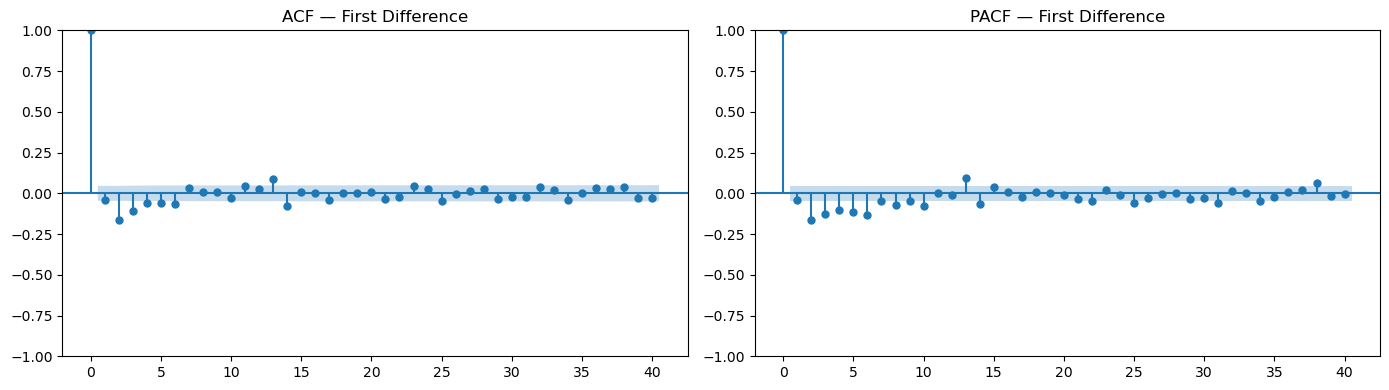

ACF/PACF suggests: p=2, d=1, q=2


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(daily.diff().dropna(), lags=40, ax=axes[0], title='ACF — First Difference')
plot_pacf(daily.diff().dropna(), lags=40, ax=axes[1], title='PACF — First Difference')
plt.tight_layout()
plt.savefig('arima_acf_pacf_Colaba.png', dpi=150)
plt.show()
print('ACF/PACF suggests: p=2, d=1, q=2')

## 4. Train/Test Split

In [6]:
# Use last ~10% as test (~184 days)
split_date = '2025-07-01'
train = daily[:split_date].iloc[:-1]
test  = daily[split_date:]

print(f'Train: {len(train)} days ({train.index[0].date()} → {train.index[-1].date()})')
print(f'Test : {len(test)} days ({test.index[0].date()} → {test.index[-1].date()})')

Train: 1642 days (2021-01-01 → 2025-06-30)
Test : 184 days (2025-07-01 → 2025-12-31)


## 5. Fit ARIMA(2,1,2)

In [7]:
model = ARIMA(train, order=(2, 1, 2))
fit   = model.fit()
print(fit.summary())

                               SARIMAX Results                                
Dep. Variable:                    AQI   No. Observations:                 1642
Model:                 ARIMA(2, 1, 2)   Log Likelihood               -7645.379
Date:                Thu, 14 May 2026   AIC                          15300.759
Time:                        20:07:29   BIC                          15327.774
Sample:                    01-01-2021   HQIC                         15310.778
                         - 06-30-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.3466      0.067     20.101      0.000       1.215       1.478
ar.L2         -0.5812      0.047    -12.481      0.000      -0.672      -0.490
ma.L1         -1.5013      0.071    -21.254      0.0

## 6. Forecast & Evaluation

In [8]:
forecast = fit.forecast(steps=len(test))
forecast.index = test.index

rmse = np.sqrt(mean_squared_error(test, forecast))
mae  = mean_absolute_error(test, forecast)
mape = np.mean(np.abs((test.values - forecast.values) / test.values)) * 100

print(f'ARIMA(2,1,2) Performance on Test Set:')
print(f'  RMSE : {rmse:.2f}')
print(f'  MAE  : {mae:.2f}')
print(f'  MAPE : {mape:.2f}%')

ARIMA(2,1,2) Performance on Test Set:
  RMSE : 44.09
  MAE  : 39.46
  MAPE : 93.75%


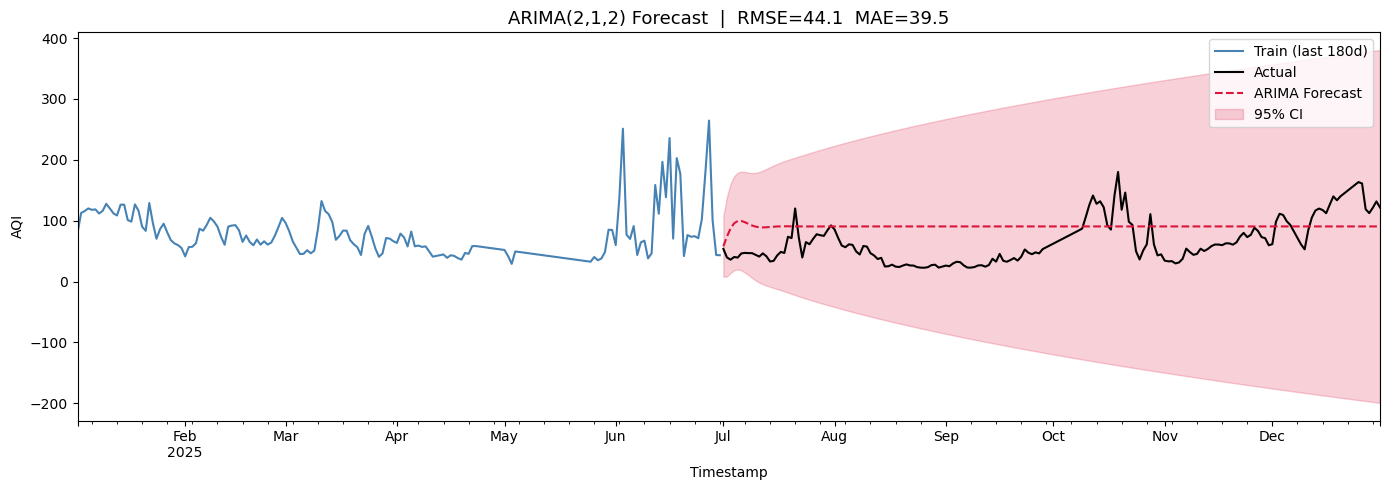

In [9]:
# Confidence interval forecast
pred_ci = fit.get_forecast(steps=len(test))
ci = pred_ci.conf_int()
ci.index = test.index

fig, ax = plt.subplots(figsize=(14, 5))
train[-180:].plot(ax=ax, label='Train (last 180d)', color='steelblue')
test.plot(ax=ax, label='Actual', color='black', linewidth=1.5)
forecast.plot(ax=ax, label='ARIMA Forecast', color='crimson', linestyle='--')
ax.fill_between(ci.index, ci.iloc[:, 0], ci.iloc[:, 1], alpha=0.2, color='crimson', label='95% CI')
ax.set_title(f'ARIMA(2,1,2) Forecast  |  RMSE={rmse:.1f}  MAE={mae:.1f}', fontsize=13)
ax.set_ylabel('AQI')
ax.legend()
plt.tight_layout()
plt.savefig('arima_forecast_Colaba.png', dpi=150)
plt.show()

## 7. Residual Diagnostics

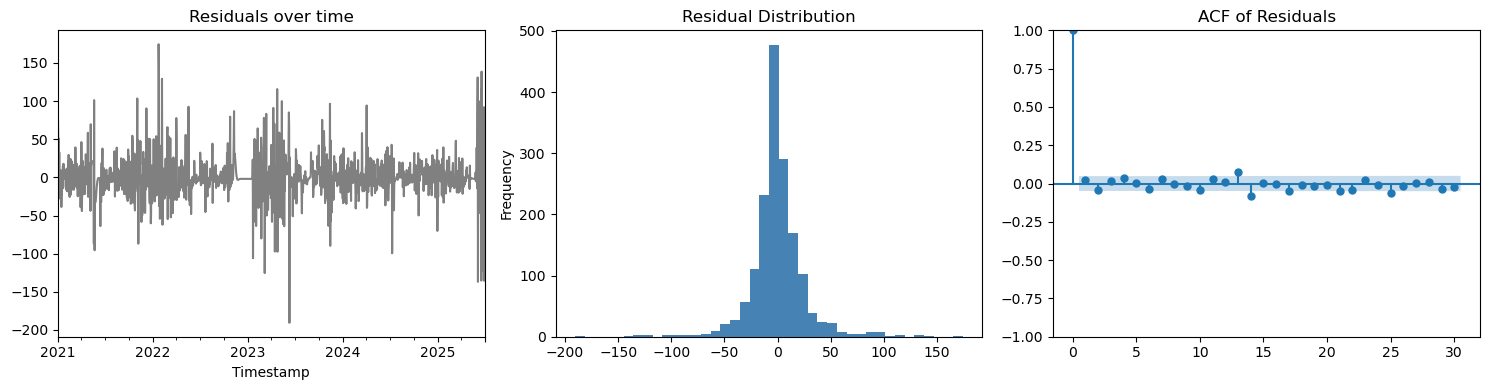

: 

In [ ]:
residuals = fit.resid
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
residuals.plot(ax=axes[0], title='Residuals over time', color='gray')
residuals.plot(kind='hist', ax=axes[1], bins=40, title='Residual Distribution', color='steelblue')
plot_acf(residuals, lags=30, ax=axes[2], title='ACF of Residuals')
plt.tight_layout()
plt.savefig('arima_residuals_Colaba.png', dpi=150)
plt.show()